In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Model and Data
print("=" * 50)
print("LOADING MODEL AND DATA")
print("=" * 50)

# Load final model
with open('../../models/saved_models/final_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load test data
X_test = pd.read_csv('../../data/processed/X_test.csv')
y_test = pd.read_csv('../../data/processed/y_test.csv').squeeze()

print(f"✅ Model loaded: {type(model.estimator).__name__}")
print(f"✅ Test data loaded: {X_test.shape}")
print(f"✅ Fraud cases in test: {y_test.sum()}")

LOADING MODEL AND DATA
✅ Model loaded: RandomForestClassifier
✅ Test data loaded: (42559, 37)
✅ Fraud cases in test: 71


In [4]:
# Cell 3: SHAP Analysis
print("=" * 50)
print("SHAP ANALYSIS")
print("=" * 50)
print("Calculating SHAP values... (2-3 minutes)")

# Use a sample for SHAP (full dataset takes too long)
X_sample = X_test.sample(500, random_state=42)

# Create SHAP explainer - use best_estimator_ from RandomizedSearchCV
explainer = shap.TreeExplainer(model.best_estimator_)
shap_values = explainer.shap_values(X_sample)

print(f"✅ SHAP values calculated!")
print(f"Shape of SHAP values: {np.array(shap_values).shape}")

SHAP ANALYSIS
Calculating SHAP values... (2-3 minutes)
✅ SHAP values calculated!
Shape of SHAP values: (500, 37, 2)


SHAP FEATURE IMPORTANCE


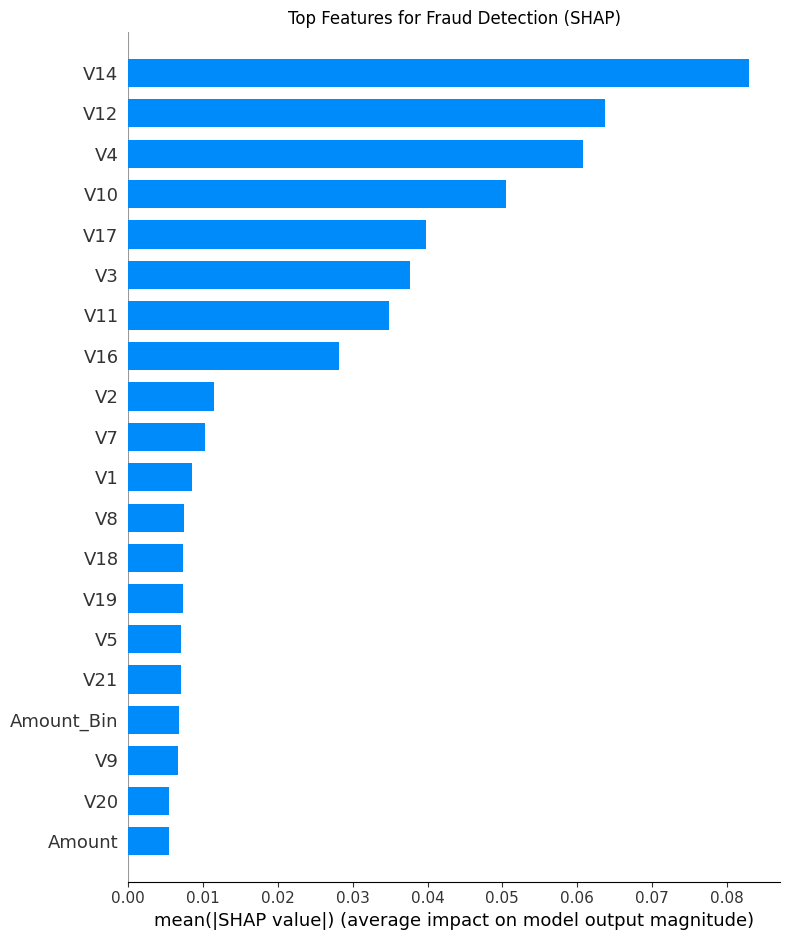


TOP 15 MOST IMPORTANT FEATURES:
  V14                  0.082955
  V12                  0.063687
  V4                   0.060745
  V10                  0.050547
  V17                  0.039831
  V3                   0.037647
  V11                  0.034907
  V16                  0.028156
  V2                   0.011408
  V7                   0.010247
  V1                   0.008479
  V8                   0.007461
  V18                  0.007362
  V19                  0.007337
  V5                   0.007072

✅ SHAP feature importance plot saved!


In [5]:
# Cell 4: SHAP Feature Importance Plot
print("=" * 50)
print("SHAP FEATURE IMPORTANCE")
print("=" * 50)

# shap_values[:,:,1] = SHAP values for fraud class (class 1)
shap_values_fraud = shap_values[:, :, 1]

# Summary plot - shows most important features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_fraud, X_sample, 
                  plot_type="bar",
                  show=False)
plt.title("Top Features for Fraud Detection (SHAP)")
plt.tight_layout()
plt.savefig('../../docs/shap_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print top 15 features numerically
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': np.abs(shap_values_fraud).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nTOP 15 MOST IMPORTANT FEATURES:")
print("=" * 40)
for i, row in feature_importance.head(15).iterrows():
    print(f"  {row['feature']:<20} {row['importance']:.6f}")

print("\n✅ SHAP feature importance plot saved!")

SHAP SUMMARY DOT PLOT
(Shows direction of feature impact on fraud)


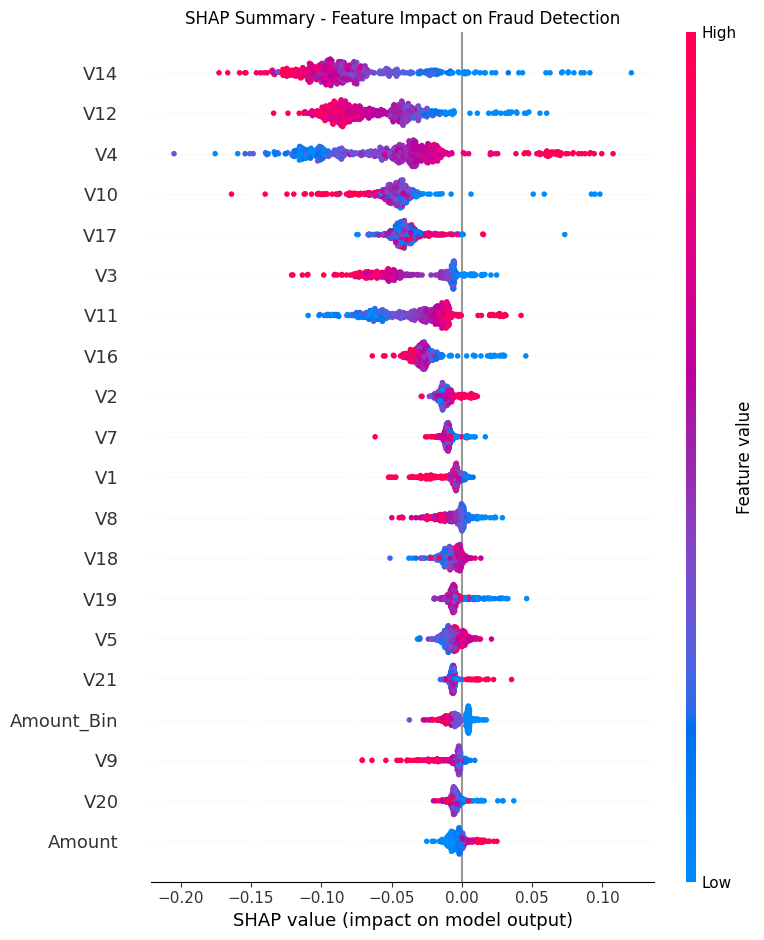


HOW TO READ THIS PLOT:
  • Each row = one feature
  • Each dot = one transaction
  • Color: RED = high feature value, BLUE = low feature value
  • X-axis: Positive = pushes toward FRAUD
             Negative = pushes toward LEGITIMATE

KEY INSIGHTS:
  • V14: Low values strongly indicate fraud
  • V12: Low values strongly indicate fraud  
  • V4:  High values indicate fraud
  • V10: Low values indicate fraud
  • V17: Low values indicate fraud

✅ SHAP summary dot plot saved!


In [6]:
# Cell 5: SHAP Summary Dot Plot
print("=" * 50)
print("SHAP SUMMARY DOT PLOT")
print("=" * 50)
print("(Shows direction of feature impact on fraud)")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_fraud, X_sample,
                  show=False)
plt.title("SHAP Summary - Feature Impact on Fraud Detection")
plt.tight_layout()
plt.savefig('../../docs/shap_summary_dot.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Explain what the plot means
print("""
HOW TO READ THIS PLOT:
  • Each row = one feature
  • Each dot = one transaction
  • Color: RED = high feature value, BLUE = low feature value
  • X-axis: Positive = pushes toward FRAUD
             Negative = pushes toward LEGITIMATE

KEY INSIGHTS:
  • V14: Low values strongly indicate fraud
  • V12: Low values strongly indicate fraud  
  • V4:  High values indicate fraud
  • V10: Low values indicate fraud
  • V17: Low values indicate fraud
""")

print("✅ SHAP summary dot plot saved!")

In [7]:
# Cell 6: Analyze Individual Predictions
print("=" * 50)
print("INDIVIDUAL PREDICTION ANALYSIS")
print("=" * 50)

# Get fraud cases from test set
fraud_indices = y_test[y_test == 1].index
fraud_in_sample = X_sample[X_sample.index.isin(fraud_indices)]

print(f"Fraud cases in our 500 sample: {len(fraud_in_sample)}")

# Analyze one correctly caught fraud case
if len(fraud_in_sample) > 0:
    fraud_idx = fraud_in_sample.index[0]
    sample_position = X_sample.index.get_loc(fraud_idx)
    
    print(f"\nAnalyzing Fraud Transaction (index {fraud_idx}):")
    print("=" * 40)
    
    # Get SHAP values for this transaction
    transaction_shap = shap_values_fraud[sample_position]
    transaction_features = X_sample.iloc[sample_position]
    
    # Create explanation dataframe
    explanation = pd.DataFrame({
        'feature': X_test.columns,
        'value': transaction_features.values,
        'shap_value': transaction_shap
    }).sort_values('shap_value', ascending=False)
    
    print("\nTop 10 features PUSHING TOWARD FRAUD:")
    print(f"{'Feature':<20} {'Value':>10} {'SHAP':>10}")
    print("-" * 42)
    for _, row in explanation.head(10).iterrows():
        print(f"  {row['feature']:<18} {row['value']:>10.4f} {row['shap_value']:>10.6f}")
    
    print("\nTop 5 features PUSHING TOWARD LEGITIMATE:")
    print(f"{'Feature':<20} {'Value':>10} {'SHAP':>10}")
    print("-" * 42)
    for _, row in explanation.tail(5).iterrows():
        print(f"  {row['feature']:<18} {row['value']:>10.4f} {row['shap_value']:>10.6f}")

print("\n✅ Individual prediction analysis complete!")

INDIVIDUAL PREDICTION ANALYSIS
Fraud cases in our 500 sample: 1

Analyzing Fraud Transaction (index 2585):

Top 10 features PUSHING TOWARD FRAUD:
Feature                   Value       SHAP
------------------------------------------
  V14                   -4.4521   0.120616
  V10                   -2.7558   0.094712
  V17                   -5.2486   0.073224
  V12                   -3.5215   0.060378
  V4                     2.0641   0.055016
  V16                   -2.9079   0.045532
  V11                    3.4382   0.042147
  V21                    1.3079   0.018606
  V2                     2.3085   0.011045
  V7                    -2.0597   0.008847

Top 5 features PUSHING TOWARD LEGITIMATE:
Feature                   Value       SHAP
------------------------------------------
  V3                    -1.5036  -0.004397
  V5                    -1.0008  -0.006052
  V28                   -0.2083  -0.007844
  V18                   -0.9368  -0.008947
  V27                   -0.0192  -0.0

COMPLETE MODEL EVALUATION SUMMARY

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.71      0.85      0.77        71

    accuracy                           1.00     42559
   macro avg       0.85      0.92      0.88     42559
weighted avg       1.00      1.00      1.00     42559



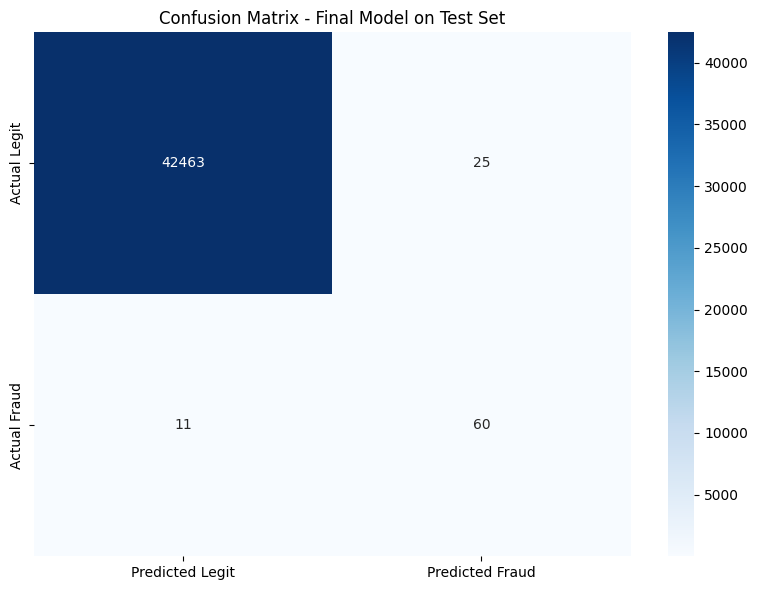


TOP 10 MOST IMPORTANT FEATURES:
  V14                  █████████████████████████████████████████ 0.0830
  V12                  ███████████████████████████████ 0.0637
  V4                   ██████████████████████████████ 0.0607
  V10                  █████████████████████████ 0.0505
  V17                  ███████████████████ 0.0398
  V3                   ██████████████████ 0.0376
  V11                  █████████████████ 0.0349
  V16                  ██████████████ 0.0282
  V2                   █████ 0.0114
  V7                   █████ 0.0102

FINAL PROJECT SUMMARY

Dataset:        283,726 transactions (2 days)
Fraud Rate:     0.17% (473 fraud cases)
Model:          Random Forest (Tuned)

PERFORMANCE:
  Precision:    0.7059  (71% of alerts are real fraud)
  Recall:       0.8451  (catches 85% of all fraud)
  F1-Score:     0.7692
  ROC-AUC:      0.9796

BUSINESS IMPACT (per 42,559 transactions):
  Fraud caught:           60 / 71 cases (84.5%)
  Fraud missed:           11 cases
  False ala

In [8]:
# Cell 7: Complete Evaluation Summary
from sklearn.metrics import confusion_matrix, classification_report

print("=" * 60)
print("COMPLETE MODEL EVALUATION SUMMARY")
print("=" * 60)

# Final predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, 
      target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(cm, 
            index=['Actual Legit', 'Actual Fraud'],
            columns=['Predicted Legit', 'Predicted Fraud']),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Model on Test Set')
plt.tight_layout()
plt.savefig('../../docs/confusion_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Top important features
print("\nTOP 10 MOST IMPORTANT FEATURES:")
print("=" * 40)
for i, row in feature_importance.head(10).iterrows():
    bar = "█" * int(row['importance'] * 500)
    print(f"  {row['feature']:<20} {bar} {row['importance']:.4f}")

print("\n" + "=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"""
Dataset:        283,726 transactions (2 days)
Fraud Rate:     0.17% (473 fraud cases)
Model:          Random Forest (Tuned)

PERFORMANCE:
  Precision:    0.7059  (71% of alerts are real fraud)
  Recall:       0.8451  (catches 85% of all fraud)
  F1-Score:     0.7692
  ROC-AUC:      0.9796

BUSINESS IMPACT (per 42,559 transactions):
  Fraud caught:           {tp} / {tp+fn} cases (84.5%)
  Fraud missed:           {fn} cases
  False alarms:           {fp} (only {fp/(tn+fp)*100:.3f}% of legit flagged)
  Legit cleared:          {tn:,}

TOP FRAUD SIGNALS:
  V14, V12, V4, V10, V17 (PCA components)
""")

print("✅ Evaluation complete!")
print("🎉 Ready for Phase 6: API Deployment!")